In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from scipy.sparse import hstack
import re
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score


In [2]:
df=pd.read_excel('moocs.xlsx')
my_df=df.copy()

In [3]:
df.head()

,Text,Urgency(1-7),CourseType,course_display_name,post_type,up_count,reads
0,Interesting! How often we say those things to ...,1.5,Education,Education/EDUC115N/How_to_Learn_Math,Comment,0.0,41.0
1,"What is \Algebra as a Math Game\"" or are you j...",3.5,Education,Education/EDUC115N/How_to_Learn_Math,Comment,0.0,55.0
2,I like the idea of my kids principal who says ...,2.5,Education,Education/EDUC115N/How_to_Learn_Math,Comment,0.0,25.0
3,"From their responses, it seems the students re...",2.5,Education,Education/EDUC115N/How_to_Learn_Math,CommentThread,0.0,0.0
4,"The boys loved math, because \there is freedom...",3.0,Education,Education/EDUC115N/How_to_Learn_Math,CommentThread,0.0,3.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29604 entries, 0 to 29603
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Text                 29603 non-null  object 
 1   Urgency(1-7)         29604 non-null  float64
 2   CourseType           29602 non-null  object 
 3   course_display_name  29591 non-null  object 
 4   post_type            29585 non-null  object 
 5   up_count             29585 non-null  float64
 6   reads                29585 non-null  float64
dtypes: float64(3), object(4)
memory usage: 1.6+ MB


In [5]:
df.describe()

,Urgency(1-7),up_count,reads
count,29604.000000,29585.000000,29585.000000
mean,2.735171,0.400980,410.736488
std,1.396435,2.016614,1245.334869
min,1.000000,0.000000,0.000000
25%,1.500000,0.000000,16.000000
50%,2.500000,0.000000,65.000000
75%,3.500000,0.000000,191.000000
max,7.000000,191.000000,9452.000000


In [6]:
df.isnull().sum()

,0
Text,1
Urgency(1-7),0
CourseType,2
course_display_name,13
post_type,19
up_count,19
reads,19


In [7]:
rows_with_null = df.isnull().any(axis=1).sum()
print(rows_with_null)

21


In [8]:
null_rows = df[df.isnull().any(axis=1)]
null_rows

,Text,Urgency(1-7),CourseType,course_display_name,post_type,up_count,reads
2801,1.\tCalculate Answer _x0007_\t- Ask students ...,3.0,NaN,Education/EDUC115N/How_to_Learn_Math,NaN,NaN,NaN
18312,NaN,2.5,Humanities,HumanitiesSciences/Econ-1/Summer2014,CommentThread,1.0,12.0
19098,Some more facts that might make you ask how mu...,3.0,Humanities,HumanitiesSciences/Econ-1/Summer2014,NaN,NaN,NaN
19589,I think your answer to Chp 3 Q6 can be improve...,2.0,Humanities,NaN,NaN,NaN,NaN
19590,ight)+hat{_x0008_eta}_1left(overline{x}-x_i\,1.0,Humanities,NaN,NaN,NaN,NaN
19591,> The bottom of Pg. 353 of the book makes the ...,5.0,Humanities,NaN,NaN,NaN,NaN
19592,You need to check your math; 10.6153 / 0.0055 ...,1.5,Humanities,NaN,NaN,NaN,NaN
19593,ight)$ term as $logleft( frac{0.5}{1-0.5} \,1.0,Humanities,NaN,NaN,NaN,NaN
19594,ight) = logleft( 1 \,1.0,Humanities,NaN,NaN,NaN,NaN
19595,I interpreted it as follows_x0007__x0007_$%_x0...,1.5,Humanities,NaN,NaN,NaN,NaN


In [9]:
my_df = my_df.dropna()
my_df.isnull().sum()

,0
Text,0
Urgency(1-7),0
CourseType,0
course_display_name,0
post_type,0
up_count,0
reads,0


In [10]:

df['Urgency(1-7)'] = df['Urgency(1-7)'].apply(lambda x: 1 if x > 4 else 0 )
my_df['Urgency(1-7)'] = my_df['Urgency(1-7)'].apply(lambda x: 1 if x > 4 else 0 )


In [11]:
le = LabelEncoder()
for col in ['CourseType', 'course_display_name', 'post_type']:
    df[col] = le.fit_transform(df[col])
    my_df[col] = le.transform(my_df[col])

df.head()


,Text,Urgency(1-7),CourseType,course_display_name,post_type,up_count,reads
0,Interesting! How often we say those things to ...,0,0,0,0,0.0,41.0
1,"What is \Algebra as a Math Game\"" or are you j...",0,0,0,0,0.0,55.0
2,I like the idea of my kids principal who says ...,0,0,0,0,0.0,25.0
3,"From their responses, it seems the students re...",0,0,0,1,0.0,0.0
4,"The boys loved math, because \there is freedom...",0,0,0,1,0.0,3.0


Text(0.5, 1.0, 'Correlation Heatmap (Original)')

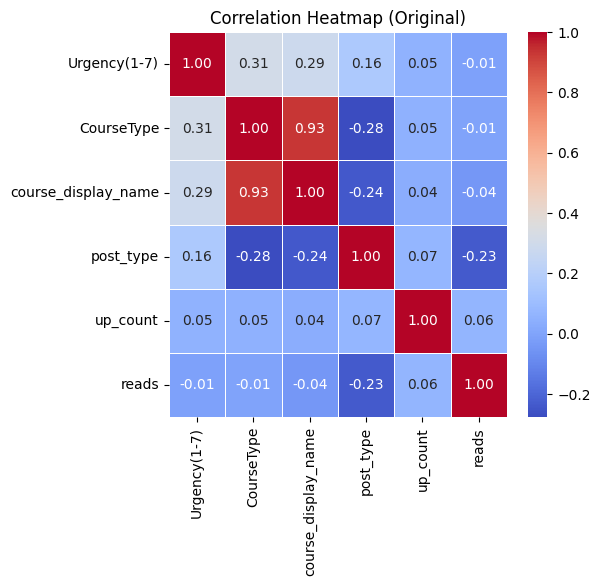

In [12]:
corr_original = df.corr(numeric_only=True)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(corr_original, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Original)")

In [13]:

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"_x[0-9a-fA-F]+_", " ", text)  # remove artifacts like _x0007_
    text = re.sub(r"[^a-zA-Z\s]", " ", text)      # remove numbers/punctuation
    text = text.lower().strip()
    return text

df['Text_clean'] = df['Text'].apply(clean_text)
my_df['Text_clean'] = my_df['Text'].apply(clean_text)


In [14]:
X = df["Text_clean"]
y = df["Urgency(1-7)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, stop_words="english")),
    ("svd", TruncatedSVD(n_components=200, random_state=42)),
    ("imputer", SimpleImputer(strategy="mean")),

    ("knn", KNeighborsClassifier(algorithm="brute", metric="cosine"))
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "svd__n_components": [100, 200, 300]
}

In [15]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring="accuracy"
)

grid.fit(X_train, y_train)


print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


y_pred = grid.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'knn__n_neighbors': 9, 'knn__weights': 'distance', 'svd__n_components': 200}
Best CV Score: 0.8300462699479088
Test Accuracy: 0.8270562404999156

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90      4809
           1       0.58      0.27      0.37      1112

    accuracy                           0.83      5921
   macro avg       0.72      0.61      0.64      5921
weighted avg       0.80      0.83      0.80      5921



In [17]:
X = my_df["Text_clean"]
y = my_df["Urgency(1-7)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, stop_words="english")),
    ("svd", TruncatedSVD(n_components=200, random_state=42)),
    ("imputer", SimpleImputer(strategy="mean")),
    ("knn", KNeighborsClassifier(algorithm="brute", metric="cosine"))
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "svd__n_components": [100, 200, 300]
}

In [18]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring="accuracy"
)

grid.fit(X_train, y_train)


print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


y_pred = grid.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'knn__n_neighbors': 11, 'knn__weights': 'distance', 'svd__n_components': 100}
Best CV Score: 0.8302205451730789
Test Accuracy: 0.8315024505661653

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.95      0.90      4790
           1       0.61      0.31      0.41      1127

    accuracy                           0.83      5917
   macro avg       0.73      0.63      0.66      5917
weighted avg       0.81      0.83      0.81      5917



Text(0.5, 1.0, 'Correlation Heatmap (Original)')

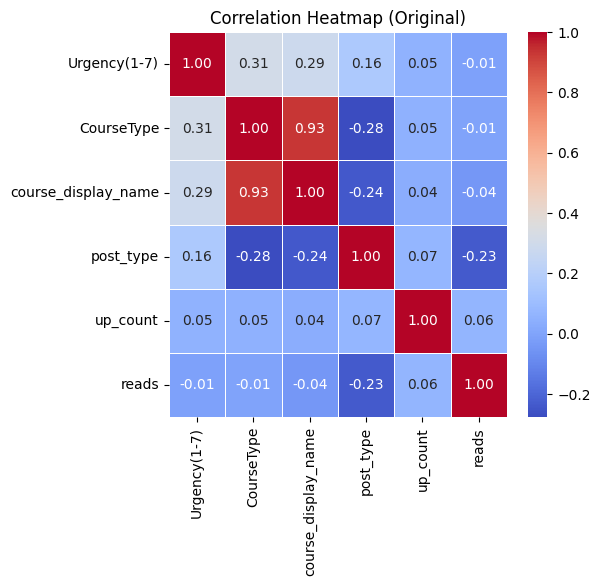

In [19]:
corr_original = df.corr(numeric_only=True)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(corr_original, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Original)")


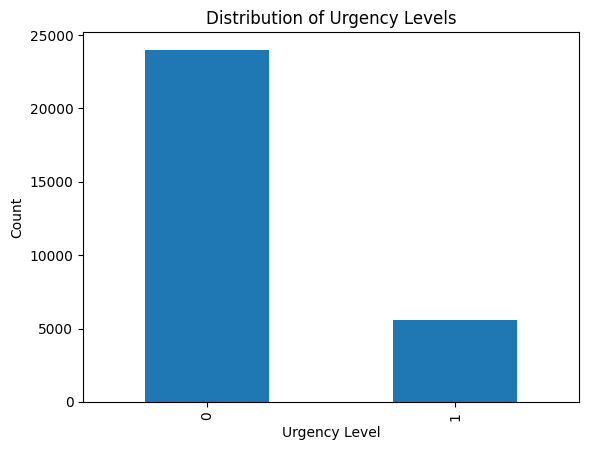

In [20]:
import matplotlib.pyplot as plt

df['Urgency(1-7)'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Urgency Level")
plt.ylabel("Count")
plt.title("Distribution of Urgency Levels")
plt.show()


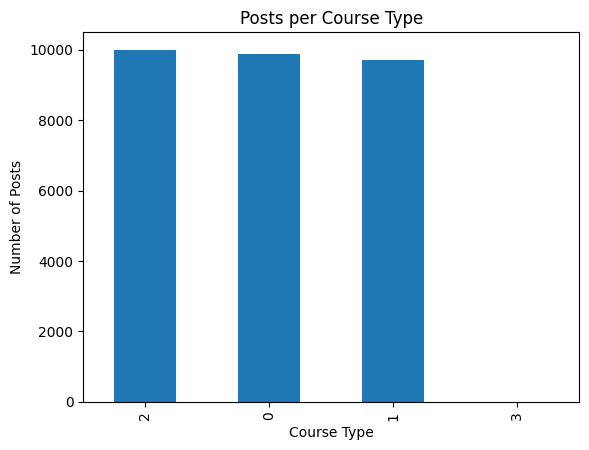

In [21]:
df['CourseType'].value_counts().plot(kind='bar')
plt.xlabel("Course Type")
plt.ylabel("Number of Posts")
plt.title("Posts per Course Type")
plt.show()


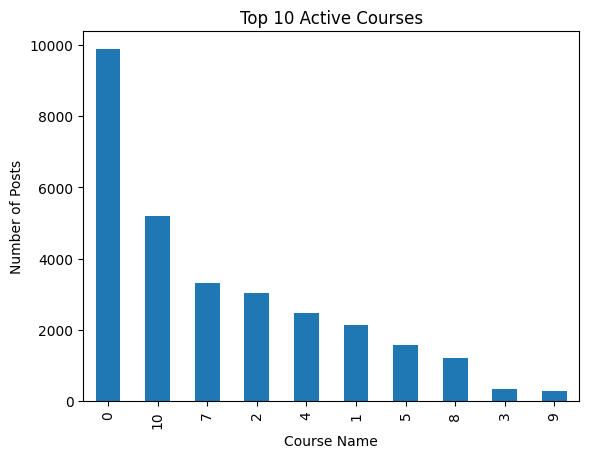

In [22]:
df['course_display_name'].value_counts().head(10).plot(kind='bar')
plt.xlabel("Course Name")
plt.ylabel("Number of Posts")
plt.title("Top 10 Active Courses")
plt.show()


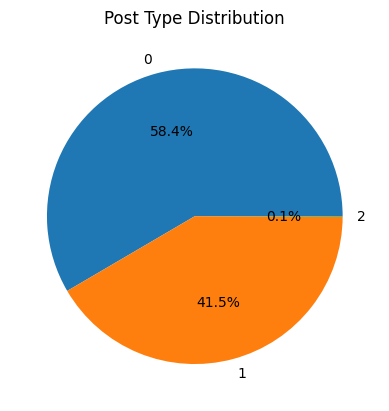

In [23]:
df['post_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Post Type Distribution")
plt.ylabel("")
plt.show()


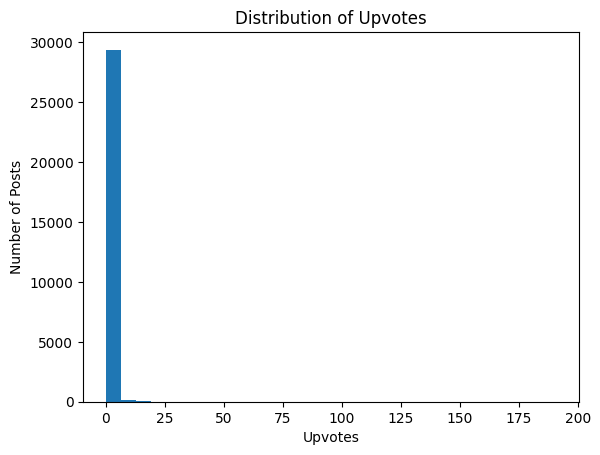

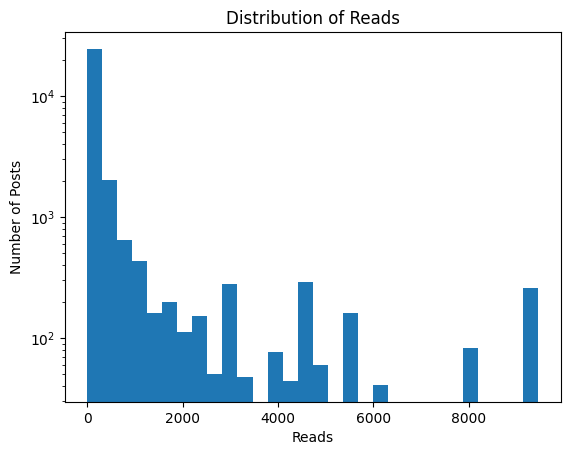

In [24]:
plt.hist(df['up_count'], bins=30)
plt.xlabel("Upvotes")
plt.ylabel("Number of Posts")
plt.title("Distribution of Upvotes")
plt.show()

plt.hist(df['reads'], bins=30)
plt.xlabel("Reads")
plt.ylabel("Number of Posts")
plt.title("Distribution of Reads")
plt.yscale('log')  # to handle skewness
plt.show()
